In [1]:
# Install Detectron2
import sys
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-y6w54d4d
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-y6w54d4d
  Resolved https://github.com/facebookresearch/detectron2.git to commit b4a4a3bd136852dae5fb1de37978dee412653e31
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 6.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7112101 sha256=251e5950c52ae6b20f4808d554cd08a405d6e50cfd93f5fb3bc5089fcbc06410
  Stored in directory: /tmp/pip-ephem-wheel-cache-qnndv236/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=fb33614516473df58c05670c7

In [2]:
# Clone the RSKT-Seg Architecture
!git clone https://github.com/LiBingyu01/RSKT-Seg_and_Pi-Seg.git

Cloning into 'RSKT-Seg_and_Pi-Seg'...
remote: Enumerating objects: 317, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 317 (delta 25), reused 18 (delta 18), pack-reused 288 (from 2)
Receiving objects: 100% (317/317), 19.40 MiB | 36.32 MiB/s, done.
Resolving deltas: 100% (143/143), done.


In [3]:
# Install requirements
%cd /kaggle/working/RSKT-Seg_and_Pi-Seg
!sed -i 's/==/>=/g' requirements.txt
!pip install -r requirements.txt

/kaggle/working/RSKT-Seg_and_Pi-Seg
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-1u6t8xl0
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-1u6t8xl0
  Resolved https://github.com/facebookresearch/detectron2.git to commit b4a4a3bd136852dae5fb1de37978dee412653e31
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [4]:
%%bash
cd /kaggle/working/RSKT-Seg_and_Pi-Seg

# Weights Setup
mkdir -p pretrained
ln -sf /kaggle/input/datasets/rachanaamraghuthama/rskt-potsdam-test-data/rskt-weights/*.pt ./pretrained/
ln -sf /kaggle/input/datasets/rachanaamraghuthama/rskt-potsdam-test-data/rskt-weights/*.pth ./pretrained/
# Explicitly link model_final.pth so the script finds it
ln -sf /kaggle/input/datasets/rachanaamraghuthama/rskt-potsdam-test-data/rskt-weights/model_final.pth ./pretrained/rskt_seg_vit_l.pth

# Bypass PyTorch 2.6 security block
sed -i "s/torch.load(Weights, map_location='cpu')/torch.load(Weights, map_location='cpu', weights_only=False)/g" RSKT_Seg/RSKT_Seg.py

# Folder Setup & Python Registry Patch
# The RSKT-Seg model has these exact folder paths hardcoded inside its source code.
mkdir -p datasets/Potsdam/imgs
mkdir -p datasets/Potsdam/D2masks
# register_Potsdam.py looks for .png files but our downloaded dataset is .tif
sed -i 's/gt_ext="png", image_ext="png"/gt_ext="tif", image_ext="tif"/g' RSKT_Seg/data/datasets/register_Potsdam.py

# 3. Link Images (stripping _RGB so Detectron2 can pair them)
SOURCE="/kaggle/input/datasets/rachanaamraghuthama/rskt-potsdam-test-data/rskt-weights"
for img in "$SOURCE"/*_RGB.tif; do
    filename=$(basename "$img")
    base="${filename%_RGB.tif}"
    ln -sf "$img" "./datasets/Potsdam/imgs/${base}.tif"
done

In [5]:
# The original images have 3 channel (RGB), but the model can only work on 1 channel, i.e, a 2D matrix 
import os
import numpy as np
from PIL import Image

source_dir = "/kaggle/input/datasets/rachanaamraghuthama/rskt-potsdam-test-data/rskt-weights"
dest_dir = "/kaggle/working/RSKT-Seg_and_Pi-Seg/datasets/Potsdam/D2masks"

# Mapped to strictly start at 0, with Clutter set to 255 (Ignore)
color2id = {
    (255, 255, 255): 0, # Impervious surfaces
    (0, 0, 255): 1,     # Building
    (0, 255, 255): 2,   # Low vegetation
    (0, 255, 0): 3,     # Tree
    (255, 255, 0): 4,   # Car
    (255, 0, 0): 255,   # Clutter/Background (IGNORE)
}

print("Converting original RGB masks directly to Contiguous Index masks...")

for filename in os.listdir(source_dir):
    if filename.endswith("_label_noBoundary.tif"):
        # Get the base name (e.g., top_potsdam_5_14.tif)
        base_name = filename.replace("_label_noBoundary.tif", ".tif")
        
        source_path = os.path.join(source_dir, filename)
        dest_path = os.path.join(dest_dir, base_name)
        
        # Open the original raw RGB image from the read-only dataset
        img = Image.open(source_path).convert('RGB')
        arr = np.array(img)
        
        mask = np.full((arr.shape[0], arr.shape[1]), 255, dtype=np.uint8)
        
        for color, class_id in color2id.items():
            matches = (arr == color).all(axis=-1)
            mask[matches] = class_id
        
        # Save directly over the old files in the working directory
        Image.fromarray(mask).save(dest_path)
        print(f"Successfully converted and saved: {base_name}")

Converting original RGB masks directly to Contiguous Index masks...
Successfully converted and saved: top_potsdam_6_13.tif
Successfully converted and saved: top_potsdam_5_14.tif
Successfully converted and saved: top_potsdam_7_13.tif
Successfully converted and saved: top_potsdam_5_15.tif
Successfully converted and saved: top_potsdam_6_14.tif
Successfully converted and saved: top_potsdam_6_15.tif


In [6]:
%%bash
cd /kaggle/working/RSKT-Seg_and_Pi-Seg

# Download a fresh Detectron2 grader
FILE="/usr/local/lib/python3.12/dist-packages/detectron2/evaluation/sem_seg_evaluation.py"
wget -qO $FILE https://raw.githubusercontent.com/facebookresearch/detectron2/main/detectron2/evaluation/sem_seg_evaluation.py

# The Final Patch with Confusion Matrix Extraction
cat << 'EOF' > patch_grader.py
file_path = "/usr/local/lib/python3.12/dist-packages/detectron2/evaluation/sem_seg_evaluation.py"
with open(file_path, "r") as f: code = f.read()

# Disable JSON
code = code.replace("self._predictions.extend(", "pass # self._predictions.extend(")

# Translates the model's 17-class output into the 6-class Potsdam format 
old_argmax = 'output["sem_seg"].argmax(dim=0)'
new_argmax = '__import__("torch").tensor([6, 6, 1, 4, 2, 0, 0, 2, 2, 1, 0, 6, 6, 6, 6, 3, 6], device=output["sem_seg"].device)[output["sem_seg"].argmax(dim=0)]'
code = code.replace(old_argmax, new_argmax)

# Clamps any out-of-bounds pixels (like Clutter/255) into the safe "Ignore" bucket so they don't crash the confusion matrix.
code = code.replace('gt[gt == self._ignore_label] = self._num_classes', 'gt[gt >= self._num_classes] = self._num_classes')
code = code.replace('pred[pred == self._ignore_label] = self._num_classes', 'pred[pred >= self._num_classes] = self._num_classes')

# Print the Confusion Matrix
target_line = "res = {}"
print_code = """
        print("\\n\\n" + "="*50)
        print("--- RAW CONFUSION MATRIX ---")
        print(self._conf_matrix)
        
        print("\\n--- PER CLASS IoU (%) ---")
        print(iou * 100)
        
        print("\\n--- PER CLASS F1-SCORE (%) ---")
        f1_scores = (2 * iou) / (1 + iou)
        print(f1_scores * 100)
        
        print("="*50 + "\\n\\n")
        res = {}
"""
code = code.replace(target_line, print_code)

with open(file_path, "w") as f: f.write(code)
print("SUCCESS: Grader patched to extract matrix")
EOF
python patch_grader.py

# Run the evaluation
python train_net.py \
  --config-file configs/vitl_336_DLRSD.yaml \
  --eval-only \
  MODEL.WEIGHTS ./pretrained/rskt_seg_vit_l.pth \
  DATALOADER.NUM_WORKERS 2 \
  DATASETS.TEST "('Potsdam_all_sem_seg',)"

SUCCESS: Grader patched to extract matrix
Command Line Args: Namespace(config_file='configs/vitl_336_DLRSD.yaml', resume=False, eval_only=True, num_gpus=1, num_machines=1, machine_rank=0, dist_url='tcp://127.0.0.1:49152', opts=['MODEL.WEIGHTS', './pretrained/rskt_seg_vit_l.pth', 'DATALOADER.NUM_WORKERS', '2', 'DATASETS.TEST', "('Potsdam_all_sem_seg',)"])
[08/02 15:00:03 detectron2]: Rank of current process: 0. World size: 1
[08/02 15:00:04 detectron2]: Environment info:
-------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy                            2.0.2
detectron2                       0.6 @/usr/local/lib/python3.12/dist-packages/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.8
detectron2 arch flags            7.5
DETECTRON2_ENV_MODULE            <not set>
PyTorch   

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Building Configuration...
[08/02 15:01:16 detectron2]: Rank of current process: 0. World size: 1
[08/02 15:01:17 detectron2]: Environment info:
-------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy                            2.0.2
detectron2                       0.6 @/usr/local/lib/python3.12/dist-packages/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.8
detectron2 arch flags            7.5
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.10.0+cu128 @/usr/local/lib/python3.12/dist-packages/torch
PyTorch debug build              False
torch._C._GLIBCXX_USE_CXX11_ABI  True
GPU available                    Yes
GPU 0,1                          Tesla T4 (arch=7.5)
Driver version                   580.159.04
CUDA_HOME                        /usr

[ WARN:0@22.544] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@22.544] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@22.544] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@22.544] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered


Generating Visualization...


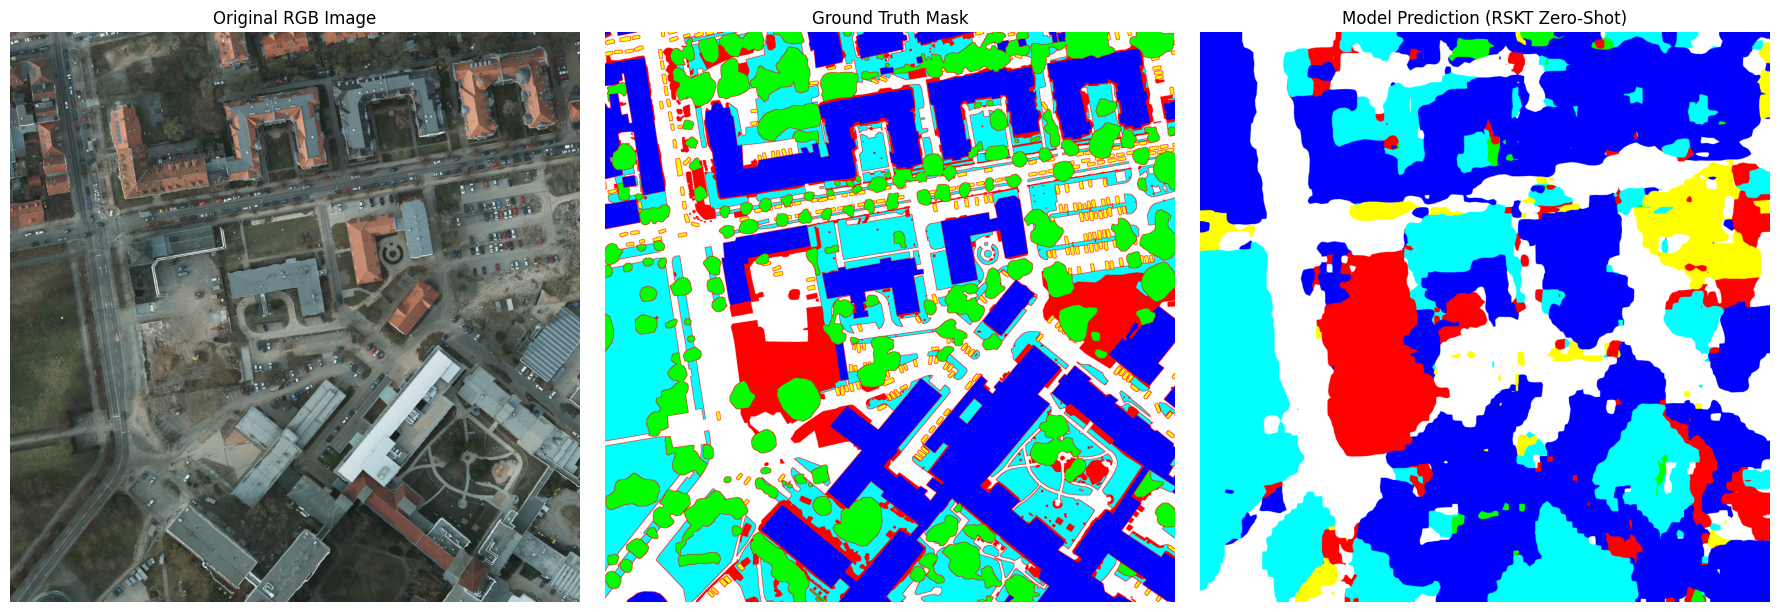

In [7]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
from PIL import Image

image_name = "top_potsdam_5_14.tif" 
base_dir = "/kaggle/working/RSKT-Seg_and_Pi-Seg/"

os.chdir(base_dir)
sys.path.insert(0, base_dir)

import train_net 
from detectron2.engine import default_argument_parser
import detectron2.data.transforms as T
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer

img_path = base_dir + "datasets/Potsdam/imgs/" + image_name
gt_path = base_dir + "datasets/Potsdam/D2masks/" + image_name

print("Building Configuration...")

args = default_argument_parser().parse_args([
    "--config-file", "configs/vitl_336_DLRSD.yaml",
    "--eval-only",
    "MODEL.WEIGHTS", "pretrained/rskt_seg_vit_l.pth"
])

cfg = train_net.setup(args)
cfg.defrost()
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading Weights...")
# Build model manually instead of using DefaultPredictor
model = build_model(cfg)
model.eval()
DetectionCheckpointer(model).load(cfg.MODEL.WEIGHTS)

print("Running Prediction...")
im = cv2.imread(img_path)
height, width = im.shape[:2]

# Format the image exactly how Detectron2 needs it
aug = T.ResizeShortestEdge([cfg.INPUT.MIN_SIZE_TEST, cfg.INPUT.MIN_SIZE_TEST], cfg.INPUT.MAX_SIZE_TEST)
image_tensor = aug.get_transform(im).apply_image(im)
image_tensor = torch.as_tensor(image_tensor.astype("float32").transpose(2, 0, 1)).to(cfg.MODEL.DEVICE)

# Inject "file_name" into the dictionary.
inputs = {
    "image": image_tensor,
    "height": height,
    "width": width,
    "file_name": img_path 
}

# Run the model without accumulating gradients
with torch.no_grad():
    outputs = model([inputs])[0]

raw_prediction = outputs["sem_seg"].argmax(dim=0).cpu()

translation_map = torch.tensor([6, 6, 1, 4, 2, 0, 0, 2, 2, 1, 0, 6, 6, 6, 6, 3, 6])
mapped_prediction = translation_map[raw_prediction].numpy()

id2color = {
    0: [255, 255, 255], # Impervious (White)
    1: [0, 0, 255],     # Building (Blue)
    2: [0, 255, 255],   # Low Veg (Cyan)
    3: [0, 255, 0],     # Tree (Green)
    4: [255, 255, 0],   # Car (Yellow)
    6: [255, 0, 0],     # Clutter/Ignore (Red)
    255: [255, 0, 0]
}

def decode_mask(mask_array):
    rgb_mask = np.zeros((mask_array.shape[0], mask_array.shape[1], 3), dtype=np.uint8)
    for class_id, color in id2color.items():
        rgb_mask[mask_array == class_id] = color
    return rgb_mask

print("Generating Visualization...")
img_rgb = np.array(Image.open(img_path))
gt_mask = np.array(Image.open(gt_path))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB Image")
axes[0].axis('off')

axes[1].imshow(decode_mask(gt_mask))
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

axes[2].imshow(decode_mask(mapped_prediction))
axes[2].set_title("Model Prediction (RSKT Zero-Shot)")
axes[2].axis('off')

plt.tight_layout()
plt.show()